### **Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])

X = df.drop("quality", axis=1)
y = df["quality"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SABINA COMMENT: Why are you using a scaler here?
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)


acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", round(acc, 4))
print("Weighted F1:", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


joblib.dump(model, "best_wine_model.pkl")
joblib.dump(scaler, "wine_scaler.pkl")
joblib.dump(X.columns.tolist(), "wine_feature_names.pkl")

print("\nModel saved successfully.")

Accuracy: 0.6931
Weighted F1: 0.6812

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.62      0.12      0.20        43
           5       0.75      0.72      0.73       428
           6       0.66      0.79      0.72       567
           7       0.67      0.58      0.62       216
           8       1.00      0.36      0.53        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.53      0.37      0.40      1300
weighted avg       0.70      0.69      0.68      1300


Confusion Matrix:
[[  0   0   3   2   1   0   0]
 [  0   5  20  17   1   0   0]
 [  0   1 308 116   3   0   0]
 [  0   2  75 449  41   0   0]
 [  0   0   5  86 125   0   0]
 [  0   0   1  10  14  14   0]
 [  0   0   0   0   1   0   0]]

Model saved successfully.


SABINA COMMENT: Any thoughts on classes 3, 4, 8, and 9? Can you reliably predict them? 

### feature

                 Feature  Importance
10               alcohol    0.122918
1       volatile acidity    0.101864
7                density    0.101107
6   total sulfur dioxide    0.090780
9              sulphates    0.086475
4              chlorides    0.085108
3         residual sugar    0.084621
5    free sulfur dioxide    0.083806
8                     pH    0.082898
2            citric acid    0.079758
0          fixed acidity    0.076506
11             wine_type    0.004161


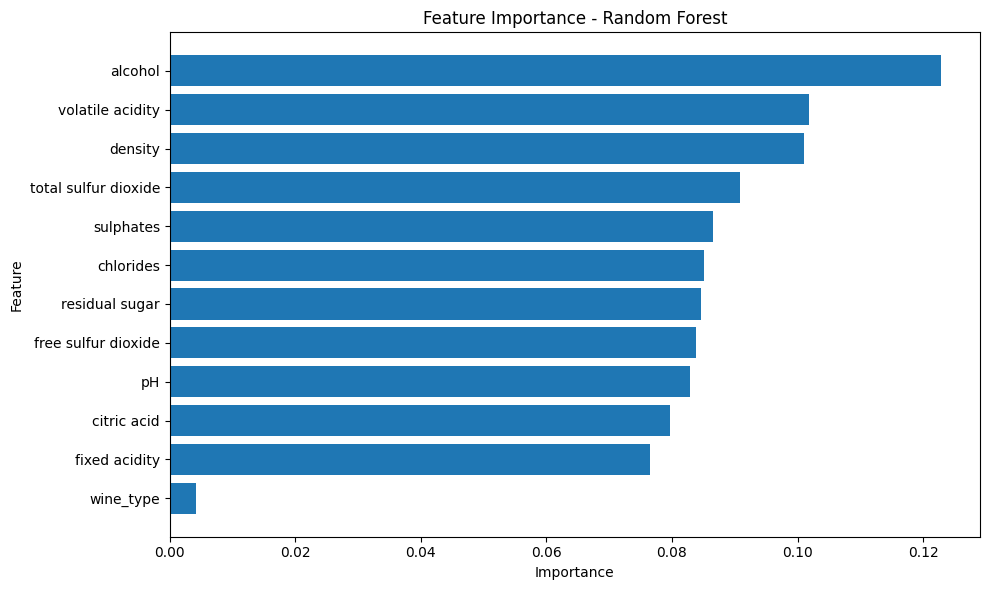

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### **confusion matrix plot**

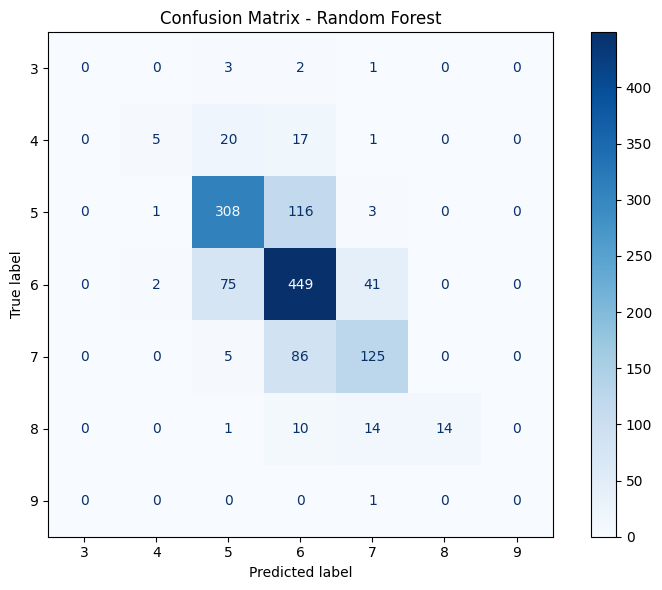

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

### results summary table

In [10]:
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1-score"],
    "Value": [acc, f1]
})

print(summary_df)

              Metric     Value
0           Accuracy  0.693077
1  Weighted F1-score  0.681187


SABINA COMMENT: Any reason we're only looking at Random Forest? What about other models?

Also, what metrics should we be using to figure out what model performs the best?